<a href="https://colab.research.google.com/github/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/blob/main/dsc_main_group_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Challenge — Seasonal Flu Vaccine Prediction


## Data Exploration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap

RANDOM_STATE = 42
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

LOAD DATA

In [ ]:
url = "https://raw.githubusercontent.com/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/main/dataset/dataset_A_training.csv"
url2 = "https://raw.githubusercontent.com/DATA-SCIENCE-HACKATHON-Group-12-32/data-science-challenge-group-A/main/dataset/dataset_A_testing.csv"


train = pd.read_csv(url)
test  = pd.read_csv(url2)
print(f"Train: {train.shape}")
print(f"Test : {test.shape}")
train.head()

Train: (4756, 31)
Test : (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,2.0,18 - 34 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,18 - 34 Years,Some College,White,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,1.0,65+ Years,College Graduate,White,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,3.0,1.0,55 - 64 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,3.0,1.0,1.0,55 - 64 Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


Exploratory Data Analysis (EDA)

Target balance check

Missing-value heatmap

Top-correlated features with target

Class-conditional distributions

The critical train/test column comparison

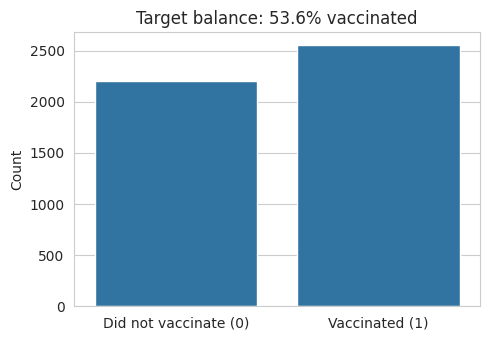

In [ ]:
#EDA - 1 Target Variable
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = train['seasonal_vaccine'].value_counts().sort_index()
sns.barplot(x=['Did not vaccinate (0)', 'Vaccinated (1)'], y=counts.values, ax=ax)
ax.set_title(f"Target balance: {counts[1]/(counts[0]+counts[1]):.1%} vaccinated")
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

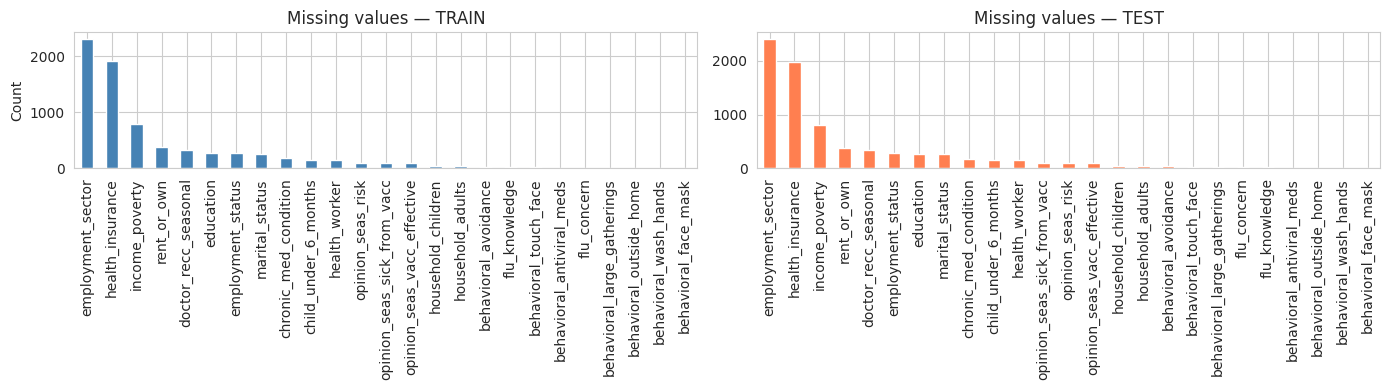

In [ ]:
#EDA - 2 Missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_train = train.isnull().sum().sort_values(ascending=False)
miss_test  = test.isnull().sum().sort_values(ascending=False)
miss_train[miss_train > 0].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Missing values — TRAIN')
axes[0].set_ylabel('Count')
miss_test[miss_test > 0].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Missing values — TEST')
plt.tight_layout(); plt.show()

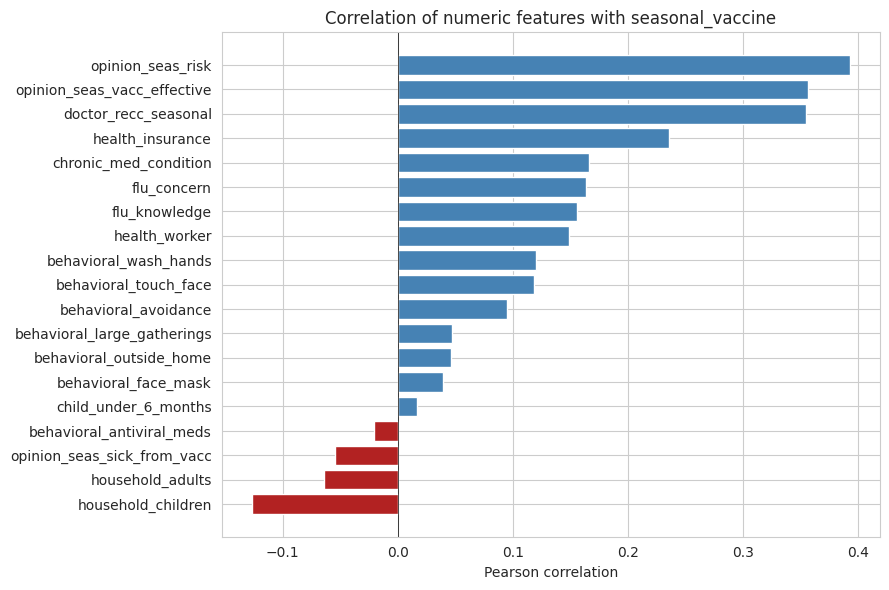

Top positive predictors:
chronic_med_condition          0.166
health_insurance               0.236
doctor_recc_seasonal           0.355
opinion_seas_vacc_effective    0.357
opinion_seas_risk              0.393


In [ ]:
# EDA - 3 Correlation of numeric features with target
num_features = train.select_dtypes(include=np.number).columns.drop(['respondent_id','seasonal_vaccine'])
corrs = train[num_features].corrwith(train['seasonal_vaccine']).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['firebrick' if c < 0 else 'steelblue' for c in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.set_title('Correlation of numeric features with seasonal_vaccine')
ax.set_xlabel('Pearson correlation')
ax.axvline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

print('Top positive predictors:')
print(corrs.tail(5).round(3).to_string())

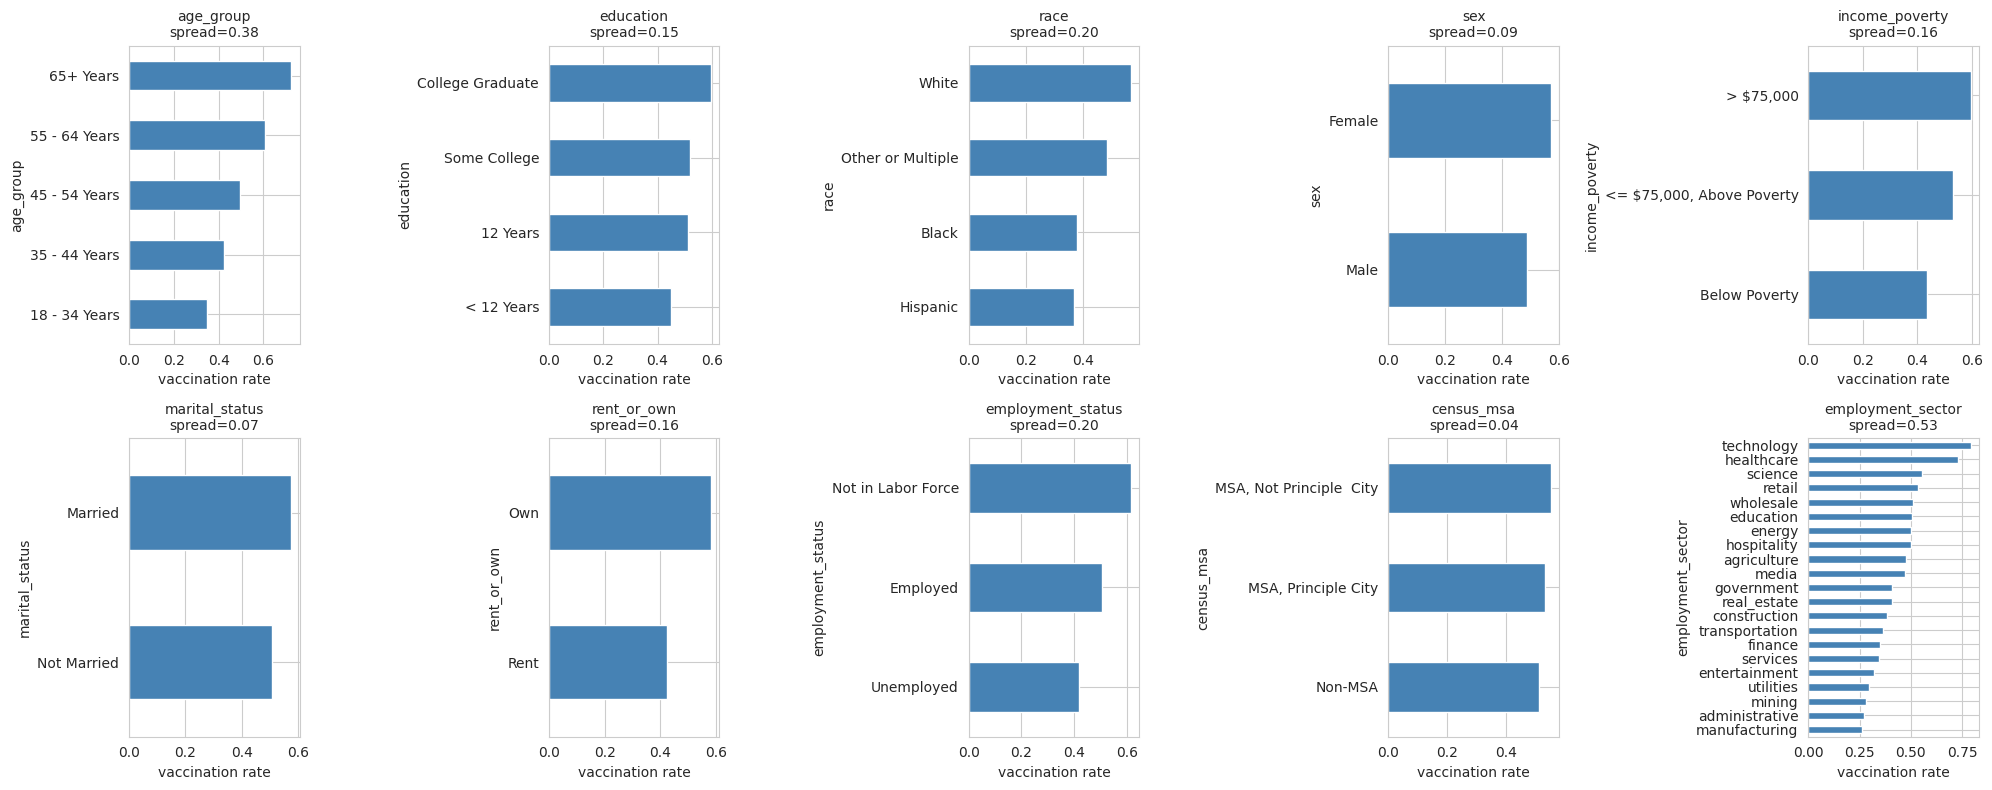

In [ ]:
# EDA - 4 Categorical target rates
cat_features = train.select_dtypes(exclude=np.number).columns.tolist()
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, cat_features):
    rates = train.groupby(col)['seasonal_vaccine'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'{col}\nspread={rates.max()-rates.min():.2f}', fontsize=10)
    ax.set_xlabel('vaccination rate')
plt.tight_layout(); plt.show()

## Preparing features and target

In [ ]:
# Target and features
y_full = train['seasonal_vaccine'].copy()
X_full = train.drop(columns=['seasonal_vaccine', 'respondent_id'])

# Test features
X_test = test.drop(columns=['respondent_id'])
test_ids = test['respondent_id']

assert list(X_full.columns) == list(X_test.columns)
print(f"X_full: {X_full.shape}   X_test: {X_test.shape}")

num_cols = X_full.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_full.select_dtypes(exclude=np.number).columns.tolist()
print(f"\nNumeric features ({len(num_cols)}): {num_cols}")
print(f"\nCategorical features ({len(cat_cols)}): {cat_cols}")

X_full: (4756, 29)   X_test: (4749, 29)

Numeric features (19): ['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']

Categorical features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [ ]:
# Identifying numeric and categorical columns
num_cols = X_full.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_full.select_dtypes(exclude=np.number).columns.tolist()
print(f"Numeric features: {len(num_cols)} -- {num_cols}")
print(f"Categorical features: {len(cat_cols)} -- {cat_cols}")

# Preprocessing ColumnTransformer
# pre-processing: scaling and Yeo-Johnson.
def build_preprocessor(X, scale_numeric=False, yeo_johnson=False):
    """Median-impute numerics, mode-impute categoricals, one-hot encode.
    Optionally StandardScaler and/or Yeo-Johnson transform the numerics.
    Yeo-Johnson handles zero/negative values, unlike log."""
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    num_steps = [('imputer', SimpleImputer(strategy='median'))]
    if yeo_johnson:
        num_steps.append(('yj', PowerTransformer(method='yeo-johnson')))
    elif scale_numeric:
        num_steps.append(('scaler', StandardScaler()))
    num_pipe = Pipeline(num_steps)

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    return ColumnTransformer([('num', num_pipe, num_cols),
                              ('cat', cat_pipe, cat_cols)])

# CV split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Multi-metric scoring
def cv_score(pipe, X, y, label=''):
    """Multi-metric CV. Returns (mean_auc, std_auc, mean_f1, mean_acc)."""
    scoring = ['roc_auc', 'f1', 'accuracy']
    res = cross_validate(pipe, X, y, scoring=scoring, cv=cv,
                         n_jobs=-1, return_train_score=False)
    auc_m, auc_s = res['test_roc_auc'].mean(), res['test_roc_auc'].std()
    f1_m         = res['test_f1'].mean()
    acc_m        = res['test_accuracy'].mean()
    if label:
        print(f"  {label:40s} ROC-AUC={auc_m:.4f}±{auc_s:.4f}  "
              f"F1={f1_m:.4f}  Acc={acc_m:.4f}")
    return auc_m, auc_s, f1_m, acc_m

Numeric features: 19 -- ['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']
Categorical features: 10 -- ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


## Data Preprocessing

In [ ]:
# Benchmarking  preprocessing techniques
print("preprocessing techniques with Logistic Regression as evaluator")

# 1. Baseline: median + onehot
exp_base = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 2. MICE imputation (IterativeImputer with BayesianRidge)
exp_mice = ColumnTransformer([
    ('num', IterativeImputer(estimator=BayesianRidge(), random_state=RANDOM_STATE, max_iter=5), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 3. KNN imputation
exp_knn = ColumnTransformer([
    ('num', KNNImputer(n_neighbors=5), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 4. Yeo-Johnson transformer
exp_yj = ColumnTransformer([
    ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                      ('yj', PowerTransformer(method='yeo-johnson'))]), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

# 5. Standard scaling
exp_sc = ColumnTransformer([
    ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                      ('s', StandardScaler())]), num_cols),
    ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                      ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

def bench_pre(pre, label):
    pipe = Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
    return cv_score(pipe, X_full, y_full, label=label)

results_pp = {}
results_pp['1. Median + onehot (baseline)'] = bench_pre(exp_base, '1. Median + onehot (baseline)')
results_pp['2. MICE (BayesianRidge)']       = bench_pre(exp_mice, '2. MICE (BayesianRidge)')
results_pp['3. KNN imputer (k=5)']          = bench_pre(exp_knn,  '3. KNN imputer (k=5)')
results_pp['4. Yeo-Johnson transform']      = bench_pre(exp_yj,   '4. Yeo-Johnson transform')
results_pp['5. StandardScaler']             = bench_pre(exp_sc,   '5. StandardScaler')


# 6. PCA — applying on scaled numerics
print("PCA benchmark (different n_components, applied after StandardScaler):")
for n_pca in [10, 20, 25]:
    pca_pipe = Pipeline([
        ('pre', exp_sc),
        ('pca', PCA(n_components=n_pca, random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    aucs = cv_score(pca_pipe, X_full, y_full, label=f'6. PCA({n_pca})')
    results_pp[f'6. PCA({n_pca}) + LogReg'] = aucs

preprocessing techniques with Logistic Regression as evaluator
  1. Median + onehot (baseline)            ROC-AUC=0.8470±0.0029  F1=0.7973  Acc=0.7811
  2. MICE (BayesianRidge)                  ROC-AUC=0.8461±0.0023  F1=0.7952  Acc=0.7782
  3. KNN imputer (k=5)                     ROC-AUC=0.8461±0.0025  F1=0.7978  Acc=0.7811
  4. Yeo-Johnson transform                 ROC-AUC=0.8490±0.0032  F1=0.7951  Acc=0.7794
  5. StandardScaler                        ROC-AUC=0.8471±0.0028  F1=0.7967  Acc=0.7805
PCA benchmark (different n_components, applied after StandardScaler):
  6. PCA(10)                               ROC-AUC=0.8289±0.0028  F1=0.7778  Acc=0.7584
  6. PCA(20)                               ROC-AUC=0.8376±0.0032  F1=0.7801  Acc=0.7635
  6. PCA(25)                               ROC-AUC=0.8386±0.0034  F1=0.7840  Acc=0.7681


## Model 1: Logistic Regression

In [ ]:
results = {}

# Model 1: Logistic Regression without scaling
print(" Model 1: Logistic Regression (without scaling) ")
m1 = Pipeline([
    ('pre', build_preprocessor(X_full, scale_numeric=False)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
results['M1 Logistic Regression (without scaling)'] = cv_score(m1, X_full, y_full, label='5-fold CV')
m1.fit(X_full, y_full)


 Model 1: Logistic Regression (without scaling) 
  5-fold CV                                ROC-AUC=0.8470±0.0029  F1=0.7973  Acc=0.7811


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'doctor_recc_sea...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

## Model 2- Logistic Regression with Scalling

In [ ]:
# Model 2: LogReg with scaling
print("Model 2: Logistic Regression + StandardScaler")
m2 = Pipeline([
    ('pre', build_preprocessor(X_full, scale_numeric=True)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
results['M2 LogReg (scaled)'] = cv_score(m2, X_full, y_full, label='5-fold CV')
m2.fit(X_full, y_full)

Model 2: Logistic Regression + StandardScaler
  5-fold CV                                ROC-AUC=0.8471±0.0028  F1=0.7967  Acc=0.7805


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

## Model 3: Random Forest

In [ ]:
# Model 3: Random Forest
print("Model 3: Random Forest (defaults)")
m3 = Pipeline([
    ('pre', build_preprocessor(X_full, scale_numeric=False)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
results['M3 RF (default)'] = cv_score(m3, X_full, y_full, label='5-fold CV')
m3.fit(X_full, y_full)

Model 3: Random Forest (defaults)
  5-fold CV                                ROC-AUC=0.8383±0.0037  F1=0.7822  Acc=0.7664


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'doctor_recc_sea...
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))])

## Model 4: Tuned Random Forest via GridSearchCV

In [ ]:
# Model 4: Tuned Random Forest via GridSearchCV
print("Model 4: Random Forest (CV-tuned, with Yeo-Johnson preprocessing)")
m4_pipe = Pipeline([
    ('pre', build_preprocessor(X_full, yeo_johnson=True)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
grid = {
    'clf__n_estimators'    : [200, 500],
    'clf__max_depth'       : [None, 10, 20],
    'clf__min_samples_leaf': [1, 4],
}
gs = GridSearchCV(m4_pipe, grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
gs.fit(X_full, y_full)
print(f"  Best params: {gs.best_params_}")
print(f"  Best CV ROC-AUC: {gs.best_score_:.4f}")


m4 = gs.best_estimator_
_, _, f1_m4, acc_m4 = cv_score(m4, X_full, y_full)
print(f"  CV F1 = {f1_m4:.4f}, CV Accuracy = {acc_m4:.4f}")
results['M4 RF (tuned)'] = (gs.best_score_, 0.0, f1_m4, acc_m4)


Model 4: Random Forest (CV-tuned, with Yeo-Johnson preprocessing)
  Best params: {'clf__max_depth': 10, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 500}
  Best CV ROC-AUC: 0.8472
  CV F1 = 0.7875, CV Accuracy = 0.7702


#Model 5: XGBoost

In [ ]:
#Model 5: XGBoost
print("Model 5: XGBoost (with Yeo-Johnson preprocessing)")
m5 = Pipeline([
    ('pre', build_preprocessor(X_full, yeo_johnson=True)),
    ('clf', xgb.XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)),
])
results['M5 XGBoost'] = cv_score(m5, X_full, y_full, label='5-fold CV')
m5.fit(X_full, y_full)

Model 5: XGBoost (with Yeo-Johnson preprocessing)
  5-fold CV                                ROC-AUC=0.8462±0.0036  F1=0.7909  Acc=0.7740


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('yj',
                                                                   PowerTransformer())]),
                                                  ['flu_concern',
                                                   'flu_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_to...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## 5. Side-by-side comparison


Model comparison (5-fold cross-validation):
                                          ROC-AUC     std      F1  Accuracy
M4 RF (tuned)                              0.8472  0.0000  0.7875    0.7702
M2 LogReg (scaled)                         0.8471  0.0028  0.7967    0.7805
M1 Logistic Regression (without scaling)   0.8470  0.0029  0.7973    0.7811
M5 XGBoost                                 0.8462  0.0036  0.7909    0.7740
M3 RF (default)                            0.8383  0.0037  0.7822    0.7664


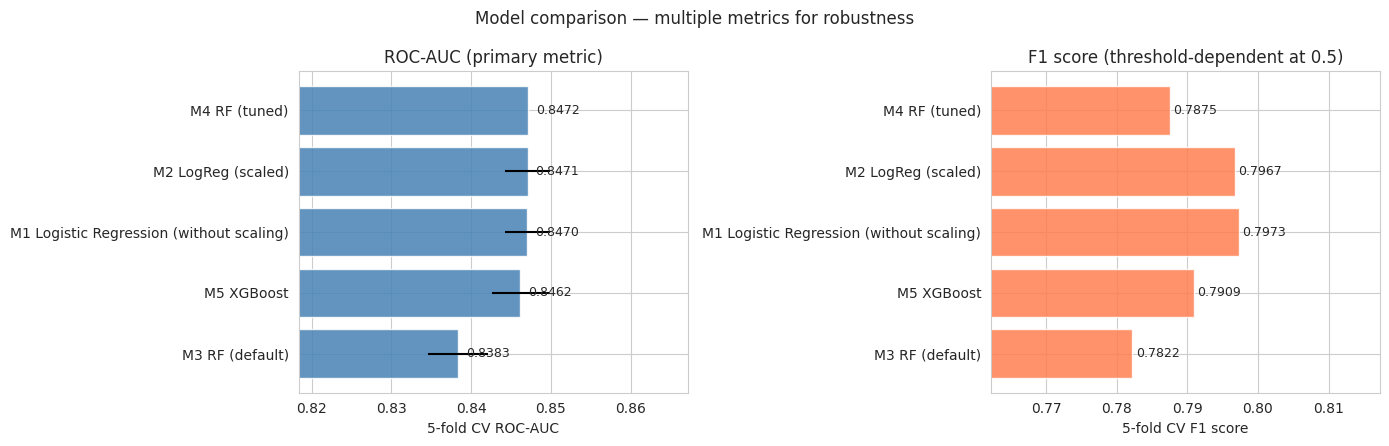

In [ ]:
# Comparison table for three metrics
res_df = pd.DataFrame(results, index=['ROC-AUC', 'std', 'F1', 'Accuracy']).T
res_df = res_df.sort_values('ROC-AUC', ascending=False)
print("Model comparison (5-fold cross-validation):")
print(res_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# ROC-AUC
axes[0].barh(res_df.index[::-1], res_df['ROC-AUC'][::-1],
             xerr=res_df['std'][::-1], color='steelblue', alpha=0.85)
axes[0].set_xlim(max(0.0, res_df['ROC-AUC'].min() - 0.02),
                 min(1.0, res_df['ROC-AUC'].max() + 0.02))
axes[0].set_xlabel('5-fold CV ROC-AUC')
axes[0].set_title('ROC-AUC (primary metric)')
for i, v in enumerate(res_df['ROC-AUC'][::-1]):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

# F1 score
axes[1].barh(res_df.index[::-1], res_df['F1'][::-1],
             color='coral', alpha=0.85)
axes[1].set_xlim(max(0.0, res_df['F1'].min() - 0.02),
                 min(1.0, res_df['F1'].max() + 0.02))
axes[1].set_xlabel('5-fold CV F1 score')
axes[1].set_title('F1 score (threshold-dependent at 0.5)')
for i, v in enumerate(res_df['F1'][::-1]):
    axes[1].text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model comparison — multiple metrics for robustness')
plt.tight_layout(); plt.show()


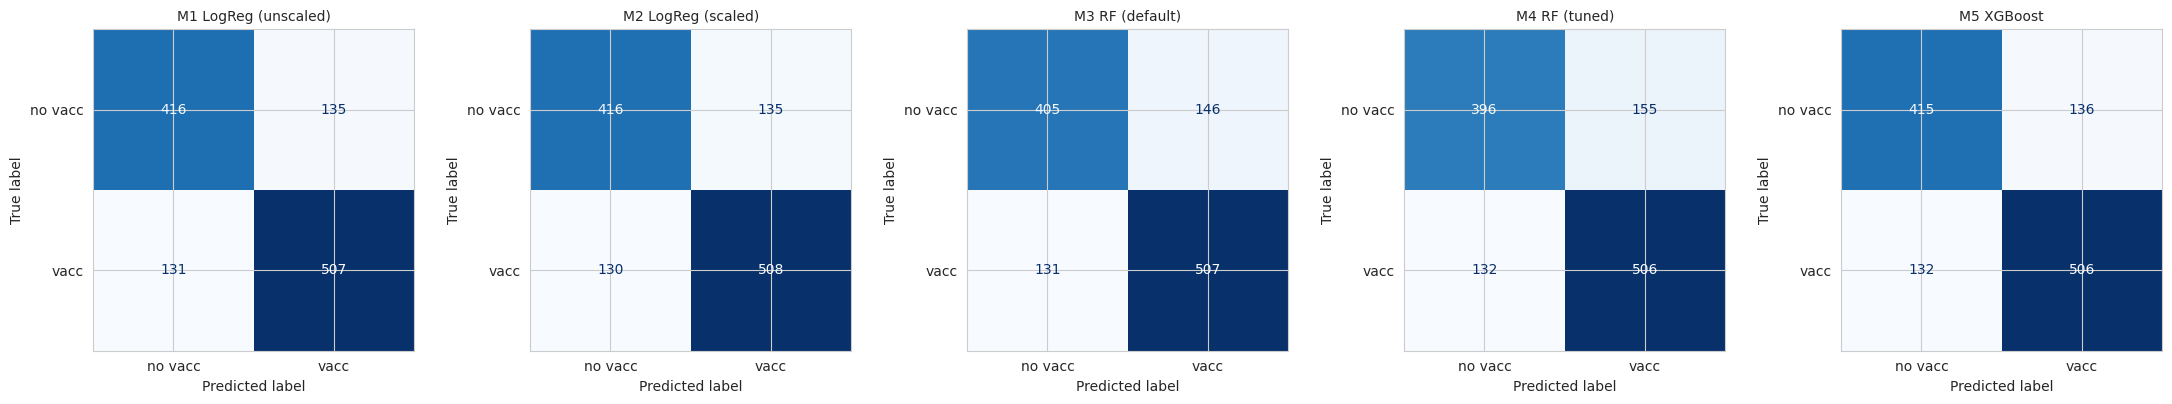

In [ ]:
#Holdout split for confusion matrices and ROC curves
Xtr_h, Xho_h, ytr_h, yho_h = train_test_split(
    X_full, y_full, test_size=0.25, stratify=y_full, random_state=RANDOM_STATE)

from sklearn.base import clone
models_holdout = {}
for name, mdl_template in [('M1 LogReg (unscaled)', m1), ('M2 LogReg (scaled)', m2),
                           ('M3 RF (default)', m3), ('M4 RF (tuned)', m4),
                           ('M5 XGBoost', m5)]:
    fresh = clone(mdl_template)
    fresh.fit(Xtr_h, ytr_h)
    models_holdout[name] = fresh

# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, mdl) in zip(axes, models_holdout.items()):
    pred = mdl.predict(Xho_h)
    ConfusionMatrixDisplay.from_predictions(
        yho_h, pred, display_labels=['no vacc', 'vacc'],
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

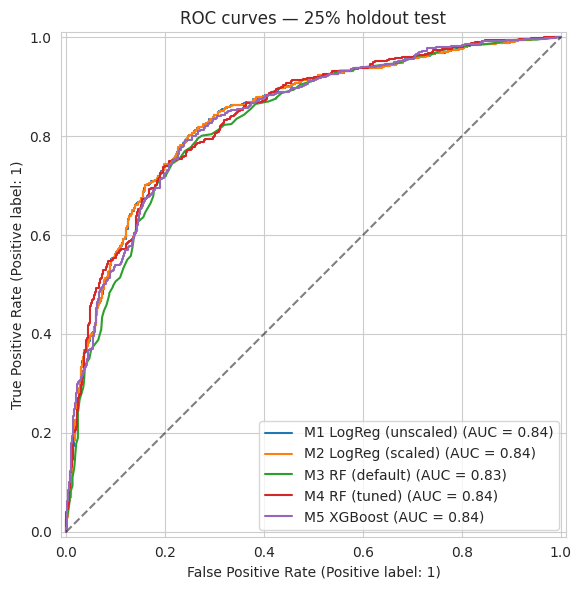

In [ ]:
# ROC curves all on one axis
fig, ax = plt.subplots(figsize=(7, 6))
for name, mdl in models_holdout.items():
    RocCurveDisplay.from_estimator(mdl, Xho_h, yho_h, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC curves — 25% holdout test')
plt.tight_layout(); plt.show()

## Explainable AI (XAI)

In [ ]:
# XGBoost pipeline for XAI
xgb_pipeline = m5
preprocessor = xgb_pipeline.named_steps['pre']
xgb_model    = xgb_pipeline.named_steps['clf']

# Feature Names for preprocessing
feat_names = preprocessor.get_feature_names_out()

# Clean names: XGBoost/SHAP reject '<', '>', '[', ']'
def clean(n):
    return (n.replace('<', 'lt').replace('>', 'gt')
             .replace('[', '(').replace(']', ')')
             .replace(',', '_'))
feat_names_clean = [clean(n) for n in feat_names]
xgb_model.get_booster().feature_names = feat_names_clean

# Sample for SHAP
X_processed = preprocessor.transform(X_full)
X_proc_df = pd.DataFrame(X_processed, columns=feat_names_clean)
X_sample = X_proc_df.sample(500, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)
print(f"Computed SHAP values for {X_sample.shape[0]} samples × {X_sample.shape[1]} features")


Computed SHAP values for 500 samples × 68 features


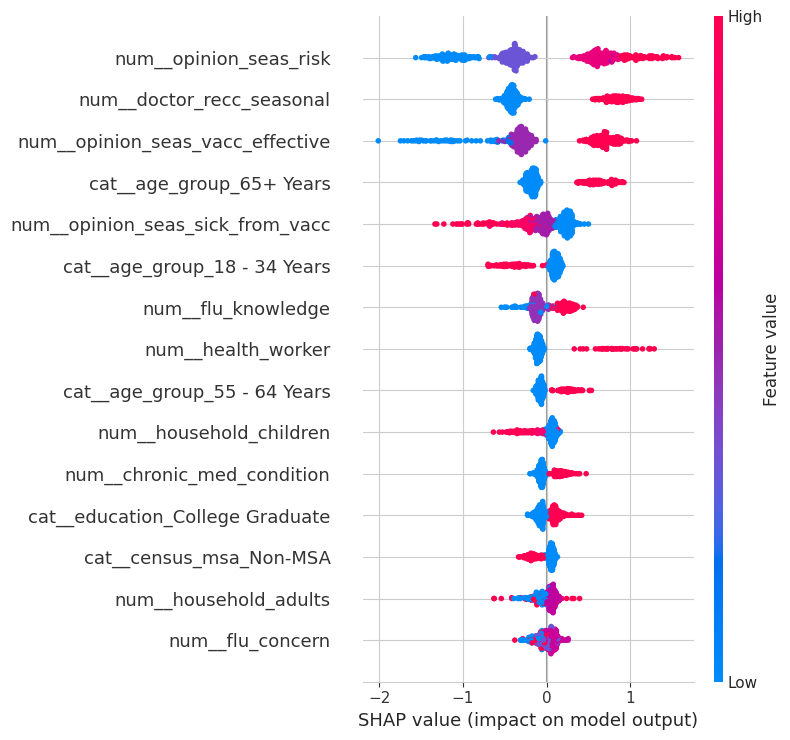

In [ ]:
# XAI 1: SHAP summary plot
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout(); plt.show()

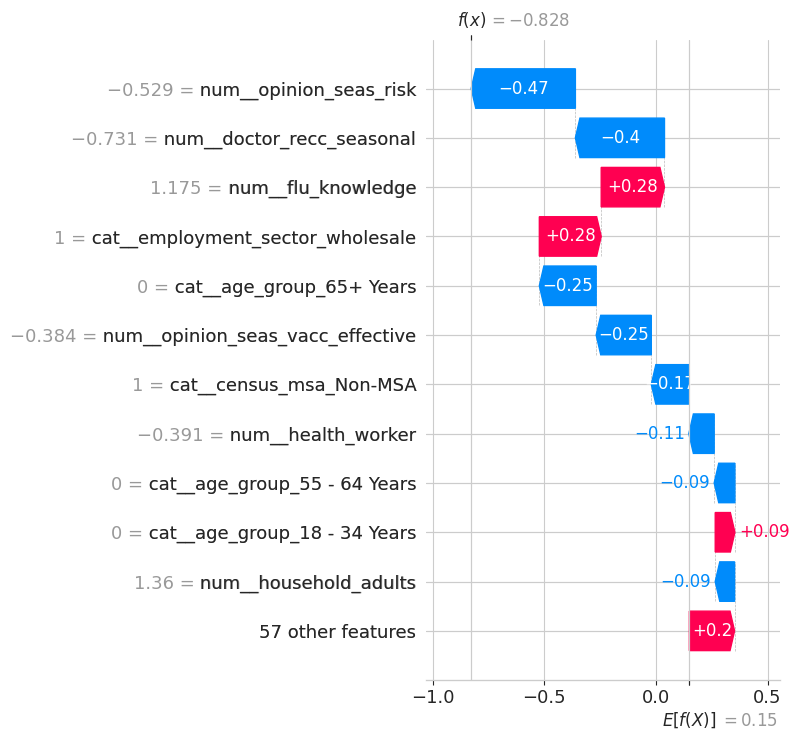


This respondent: predicted vaccination probability = 0.304


In [ ]:
#XAI 2: SHAP waterfall
idx = 0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx].values,
        feature_names=X_sample.columns.tolist(),
    ),
    max_display=12, show=False)
plt.tight_layout(); plt.show()

prob = xgb_model.predict_proba(X_sample.iloc[[idx]])[0, 1]
print(f"\nThis respondent: predicted vaccination probability = {prob:.3f}")

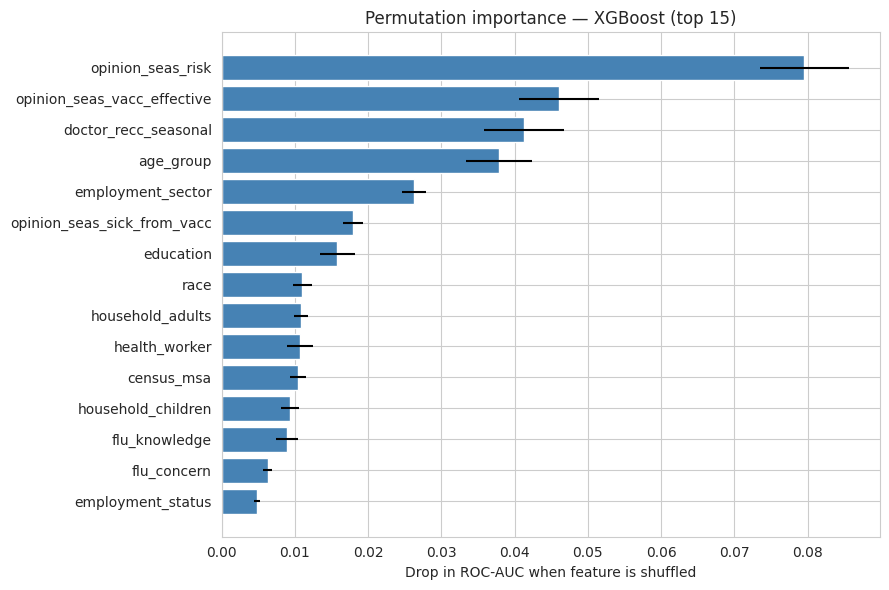

In [ ]:
#XAI 3: Permutation importance
perm = permutation_importance(xgb_pipeline, Xho_h, yho_h,
                              n_repeats=10, random_state=RANDOM_STATE,
                              scoring='roc_auc', n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': X_full.columns,
    'importance_mean': perm.importances_mean,
    'importance_std' : perm.importances_std,
}).sort_values('importance_mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
        xerr=perm_df['importance_std'][::-1], color='steelblue')
ax.set_xlabel('Drop in ROC-AUC when feature is shuffled')
ax.set_title('Permutation importance — XGBoost (top 15)')
plt.tight_layout(); plt.show()

## Submission files

In [83]:
# ROC-AUC is our primary metric, F1 and Accuracy reported for transparency.
ranking = sorted(results.items(), key=lambda kv: -kv[1][0])
print("Submission ranking by 5-fold CV ROC-AUC (best → worst):")
for i, (name, (auc, _, f1, acc)) in enumerate(ranking, 1):
    print(f"  {i}. {name:25s} ROC-AUC={auc:.4f}  F1={f1:.4f}  Acc={acc:.4f}")

Submission ranking by 5-fold CV ROC-AUC (best → worst):
  1. M4 RF (tuned)             ROC-AUC=0.8472  F1=0.7875  Acc=0.7702
  2. M2 LogReg (scaled)        ROC-AUC=0.8471  F1=0.7967  Acc=0.7805
  3. M1 Logistic Regression (without scaling) ROC-AUC=0.8470  F1=0.7973  Acc=0.7811
  4. M5 XGBoost                ROC-AUC=0.8462  F1=0.7909  Acc=0.7740
  5. M3 RF (default)           ROC-AUC=0.8383  F1=0.7822  Acc=0.7664


In [87]:
# Map model names back to fitted pipelines (already fitted on FULL train data)
name_to_model = {
    'M1 Logistic Regression (without scaling)': m1,
    'M2 LogReg (scaled)'  : m2,
    'M3 RF (default)'     : m3,
    'M4 RF (tuned)'       : m4,
    'M5 XGBoost'          : m5,
}

import os
os.makedirs('submissions', exist_ok=True)

# Predict and write each
for rank, (name, _) in enumerate(ranking, 1):
    mdl = name_to_model[name]
    proba = mdl.predict_proba(X_test)[:, 1]   # probability of class 1
    pred  = (proba >= 0.5).astype(int)        # 0/1 prediction
    out = pd.DataFrame({
        'respondent_id': test_ids,
        'seasonal_vaccine': pred,
        'probability': proba.round(4)
    })
    tag = name.split()[0].lower()
    fname = f'submissions/{rank}_{tag}.csv'
    out.to_csv(fname, index=False)
    print(f'wrote {fname} ({len(out)} rows)  -- {name}')


wrote submissions/1_m4.csv (4749 rows)  -- M4 RF (tuned)
wrote submissions/2_m2.csv (4749 rows)  -- M2 LogReg (scaled)
wrote submissions/3_m1.csv (4749 rows)  -- M1 Logistic Regression (without scaling)
wrote submissions/4_m5.csv (4749 rows)  -- M5 XGBoost
wrote submissions/5_m3.csv (4749 rows)  -- M3 RF (default)


In [88]:
# Sanity check the predictions
import os
files = sorted(os.listdir('submissions'))
for f in files:
    df = pd.read_csv(f'submissions/{f}')
    print(f"{f}: shape={df.shape}, predicted_positive={df['seasonal_vaccine'].mean():.3f}, "
          f"mean_prob={df['probability'].mean():.3f}")
print('\nNotes:')
print('  - predicted_positive ~0.45-0.55 matches train balance.')
print('  - All files have the same number of rows as the test set (4749).')

1_m4.csv: shape=(4749, 3), predicted_positive=0.569, mean_prob=0.547
2_m2.csv: shape=(4749, 3), predicted_positive=0.565, mean_prob=0.550
3_m1.csv: shape=(4749, 3), predicted_positive=0.565, mean_prob=0.550
4_m5.csv: shape=(4749, 3), predicted_positive=0.564, mean_prob=0.551
5_m3.csv: shape=(4749, 3), predicted_positive=0.575, mean_prob=0.551

Notes:
  - predicted_positive ~0.45-0.55 matches train balance.
  - All files have the same number of rows as the test set (4749).
